In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("gold_price_data.csv")
df.isnull().sum()
df.duplicated().sum()
df.shape
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [2]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


<Axes: >

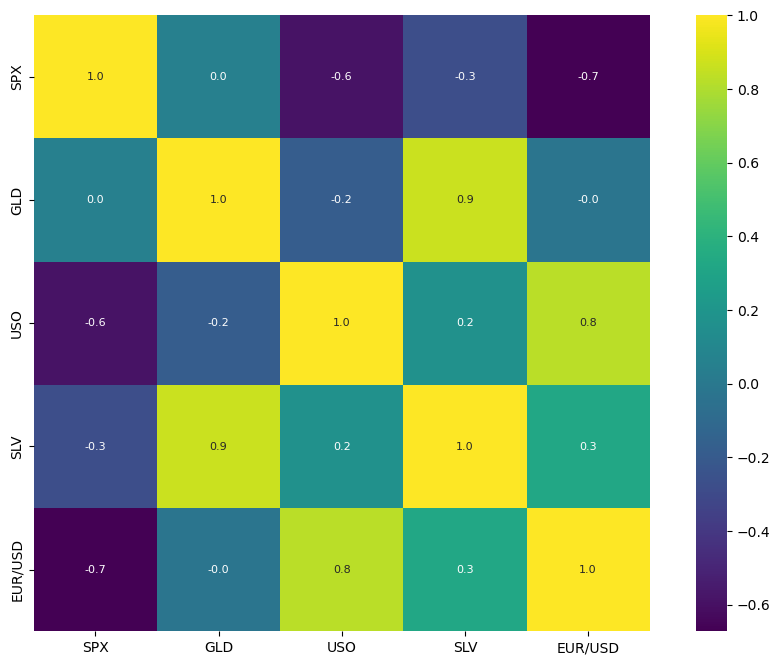

In [3]:
plt.figure(figsize=(12,8))
correlation = df.drop(columns = "Date")
sns.heatmap(correlation.corr(),cbar = True,square = True,fmt = ".1f" , annot = True , annot_kws = {"size" : 8},cmap="viridis")

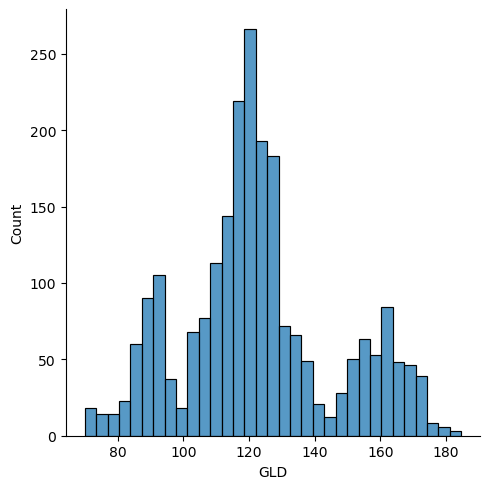

In [4]:
# checking distribution of Gold
sns.displot(df["GLD"])

In [5]:
# Spliting features and targets
x = df.drop(columns=["Date","GLD"])
y = df["GLD"]

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Regression Model

In [7]:
random_forest_model = RandomForestRegressor(n_estimators=100)
random_forest_model.fit(x_train,y_train)
pre = random_forest_model.predict(x_test)
print(f"Random Forest model : {r2_score(pre,y_test)}")

Random Forest model : 0.9894860871163167


# Decision Tree Model

In [9]:
decision_tree_model = DecisionTreeRegressor(max_depth=100,random_state=2)
decision_tree_model.fit(x_train,y_train)
pre2 = decision_tree_model.predict(x_test)
print(f"Random Forest model : {r2_score(pre2,y_test)}")

Random Forest model : 0.985825076696877


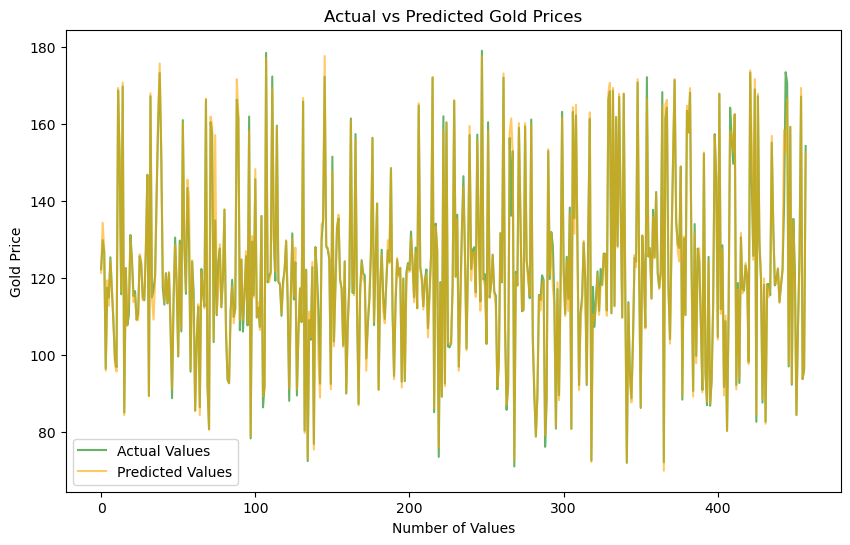

In [21]:
y_test_list = list(y_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test_list, color="green", label="Actual Values", alpha=0.6)
plt.plot(pre2, color="orange", label="Predicted Values", alpha=0.6)

plt.title("Actual vs Predicted Gold Prices")
plt.xlabel("Number of Values")
plt.ylabel("Gold Price")
plt.legend()

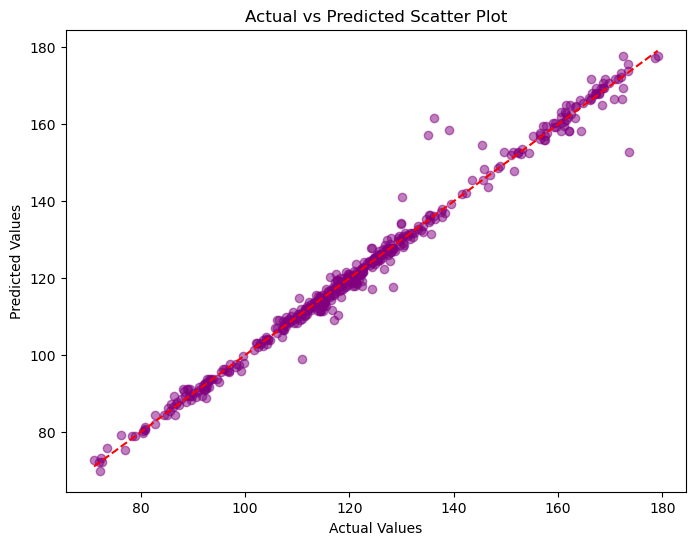

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pre2, color="purple", alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--") # Diagonal reference line

plt.title("Actual vs Predicted Scatter Plot")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

In [34]:
# Making Predictive System
input_data = (2723.070068,14.41,15.74,1.191753)
arr = np.array(input_data)
rs = arr.reshape(1,-1)
a  = decision_tree_model.predict(rs)
print(f"Gold Price is {a[0]:.2f}")

Gold Price is 125.18


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
